# Student Performance

## Overview

### Machine Learning Task
This project analyzes student performance data from a Portuguese school system to develop a machine learning model that predicts students' final grades based on selected features. The model is intended to help identify students who may benefit from additional academic assistance or intervention.

The project includes data cleaning and preparation, exploratory analysis, feature selection, regression model development and comparison, hyperparameter tuning, and evaluation of model performance.

In [1]:
import pandas as pd
import numpy as np
import sklearn

#### Import the Data

In [2]:
students = pd.read_csv('student-mat.csv')

#### Initial Data Check

In [3]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 35 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   school       395 non-null    object 
 1   sex          395 non-null    object 
 2   age          383 non-null    float64
 3   address      395 non-null    object 
 4   famsize      395 non-null    object 
 5   Pstatus      395 non-null    object 
 6   Medu         395 non-null    int64  
 7   Fedu         395 non-null    int64  
 8   Mjob         395 non-null    object 
 9   Fjob         395 non-null    object 
 10  reason       395 non-null    object 
 11  guardian     395 non-null    object 
 12  traveltime   395 non-null    int64  
 13  studytime    395 non-null    int64  
 14  failures     395 non-null    int64  
 15  schoolsup    395 non-null    object 
 16  famsup       395 non-null    object 
 17  paid         395 non-null    object 
 18  activities   395 non-null    object 
 19  nursery 

In [4]:
students.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences_G1', 'absences_G2', 'absences_G3', 'G1',
       'G2', 'G3'],
      dtype='object')

In [5]:
students.shape

(395, 35)

#### Filter the target

In [6]:
target = students['G3']

#### Split the data into training and test sets

In [7]:
students_features = students.drop('G3', axis = 1)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    students_features, target, 
    test_size=0.2, 
    random_state=42)

## Explore the Data

In [9]:
X_train.describe()

# age and absences have higher ranges than other numeric features; 
# may need to scale features for accurate comparison

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences_G1,absences_G2,absences_G3,G1,G2
count,305.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,306.000000,309.000000,307.000000,316.000000,316.000000
mean,16.747541,2.734177,2.544304,1.430380,2.047468,0.335443,3.943038,3.218354,3.161392,1.500000,2.344937,3.518987,0.709150,1.110032,4.312704,10.933544,10.651899
std,1.274188,1.080375,1.078476,0.688842,0.836258,0.735588,0.885464,1.020323,1.119480,0.903257,1.296395,1.410714,1.373179,1.490510,5.064931,3.216823,3.755930
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,8.000000,9.000000
50%,17.000000,3.000000,3.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,0.000000,1.000000,4.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,1.000000,2.000000,6.000000,13.000000,13.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,12.000000,11.000000,36.000000,19.000000,19.000000


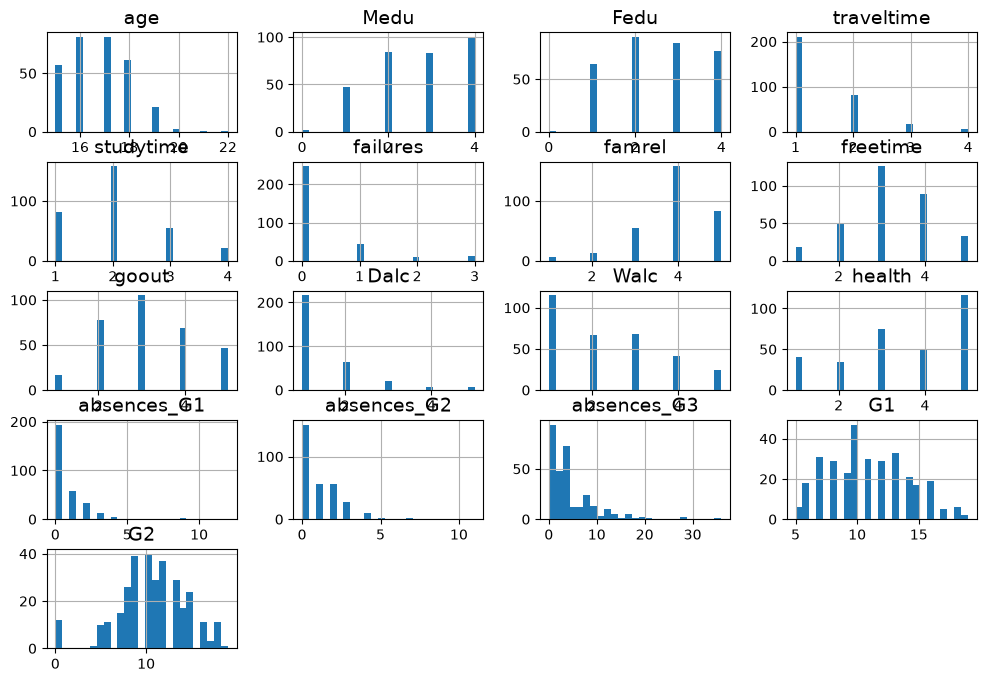

In [10]:
import matplotlib.pyplot as plt

# Review distribution of features; confirmed range differences, otherwise not super helpful

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# plots histograms of numerical data
X_train.hist(bins=25, figsize=(12, 8))
plt.show()

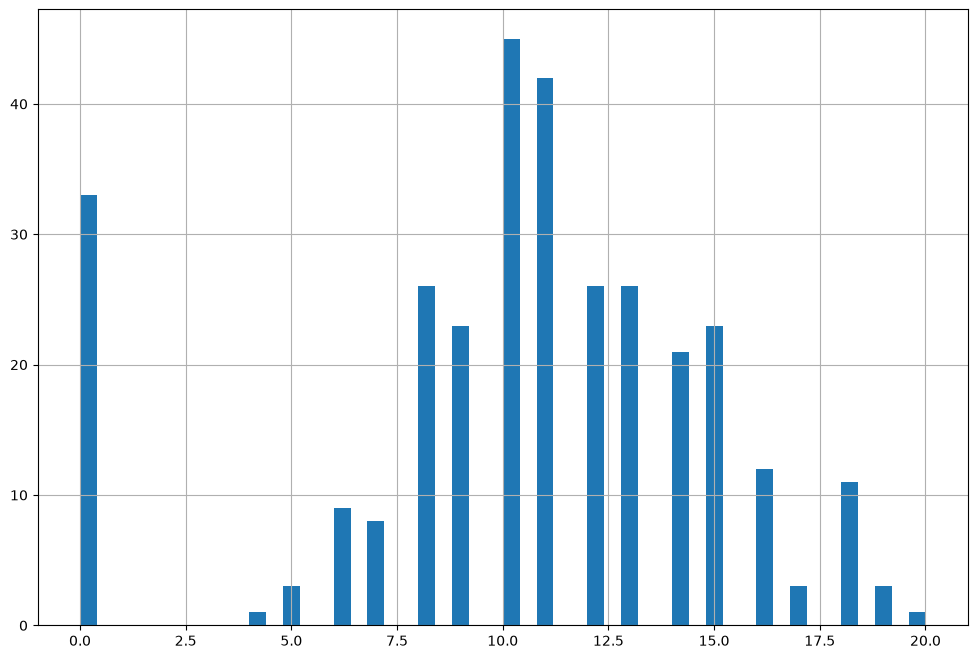

In [11]:
# Review distribution of target;
# high occurrence of the lowest grades; without this spike, the distribution would be right-skewed;


plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# plots histograms of numerical data
y_train.hist(bins=50, figsize=(12, 8))
plt.show()

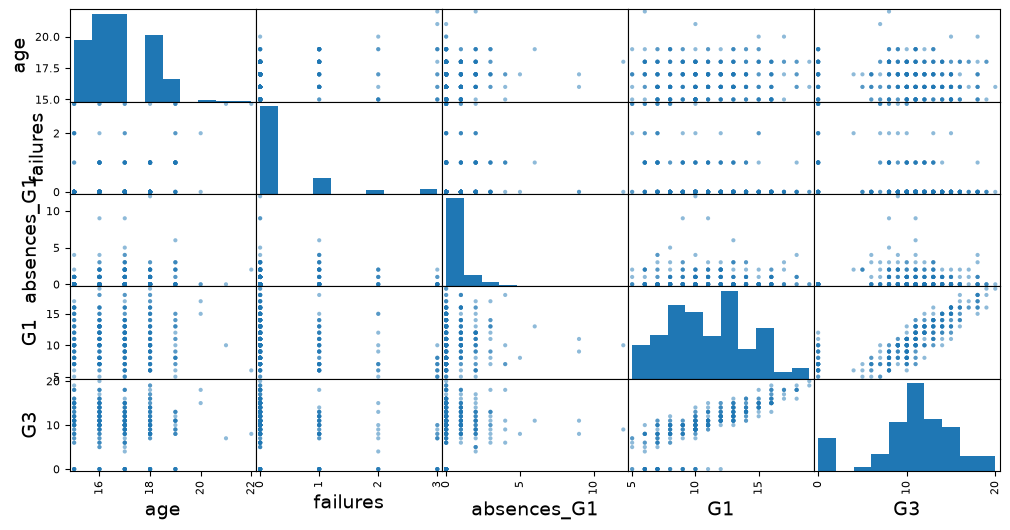

In [12]:
# plot select numeric values
from pandas.plotting import scatter_matrix

# select only a few numeric attributes from the training data
col_attributes = ['age','failures','absences_G1','G1']

# combine training features and target into DataFrame
combined_df = pd.concat([X_train[col_attributes], y_train], axis=1)

# plots scatterplots and histograms when variable is compared against itself
scatter_matrix(combined_df, figsize=(12, 6))
plt.show()

# Impression: Only linear relationship seen involves G1, which is due to multicollinearity 
# rather than independent predictive relationship

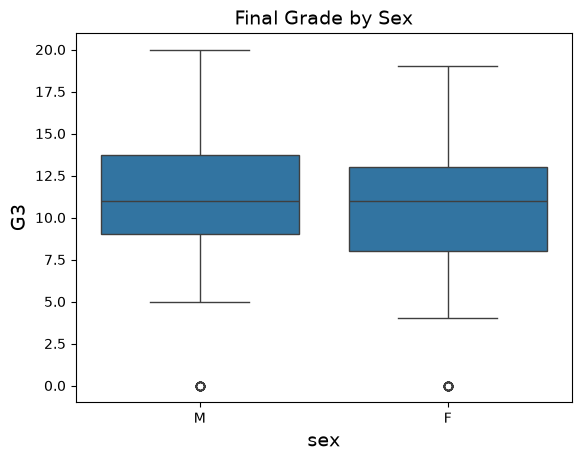

In [13]:
import seaborn as sns

sns.boxplot(x='sex', y=y_train, data=X_train.join(y_train))
plt.title('Final Grade by Sex')
plt.show()

# Impression: IQRs overlap a lot; median G3 same/near same for males & females; sex not really strong predictor

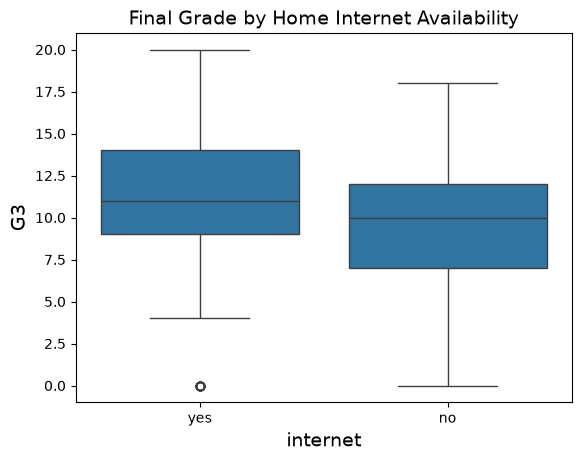

In [14]:
sns.boxplot(x='internet', y=y_train, data=X_train.join(y_train))
plt.title('Final Grade by Home Internet Availability')
plt.show()

# Impression: IQRs overlap less than sex; 
# median grades still close, but noticeable difference, possible predictor

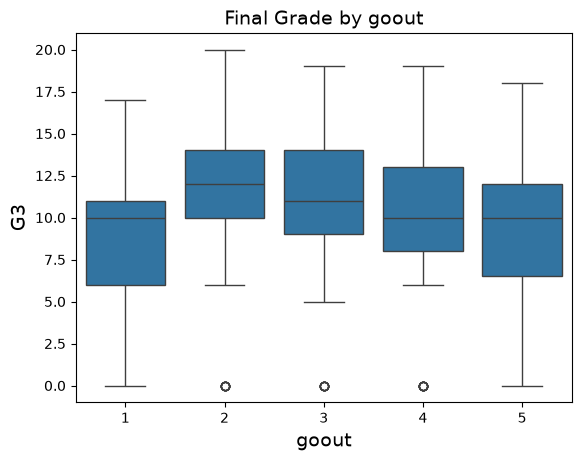

In [15]:
sns.boxplot(x='goout', y=y_train, data=X_train.join(y_train))
plt.title('Final Grade by goout')
plt.show()

# Impression: IQRs overlap moderately; 
# median grades noticeably different, possible predictor

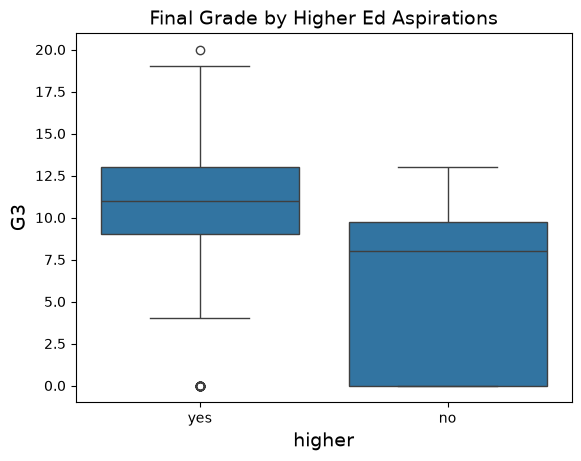

In [16]:
sns.boxplot(x='higher', y=y_train, data=X_train.join(y_train))
plt.title('Final Grade by Higher Ed Aspirations')
plt.show()

# Impression: IQRs overlap minimally; 
# median grades noticeably different, seemingly strong predictor

## Prepare the Data

### Feature Selection

Based on the exploratory analysis, selected features were grouped as numeric, categorical, or ordinal for preprocessing and model development.


In [17]:
numeric_columns = ['age','absences_G1','absences_G2','absences_G3','G1','G2']

categorical_columns = ['higher']

ordinal_columns = ['goout']

### Custom Transformer

A custom transformer combines the three absence variables into a single `absences_sum` feature and can optionally remove the first- and second-term grades (`G1` and `G2`).

Because `G1` and `G2` are highly correlated with the final grade (`G3`), models are evaluated both with and without these prior grades. Excluding them creates a more challenging prediction task but allows predictions to be made earlier in the academic year.


In [18]:
from sklearn.base import BaseEstimator, TransformerMixin

class FinalProjectTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, drop_grades=True):
        self.drop_grades = drop_grades

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        
        X = X.copy()

        X['absences_sum'] = X['absences_G1'] + X['absences_G2'] + X['absences_G3']
        X = X.drop(['absences_G1', 'absences_G2', 'absences_G3'], axis=1)
        
        if self.drop_grades == True:
            X = X.drop(['G1', 'G2'], axis = 1)
            return X
        else:
            return X

### Data Pipelines

Separate preprocessing pipelines were created for numeric, categorical, and ordinal features and combined using a column transformer.

Two versions of the transformed data were created: one including `G1` and `G2` and one excluding them.


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [20]:
numeric_pipeline_with_grades = Pipeline([
    ('imputer', SimpleImputer(strategy="median").set_output(transform="pandas")),
    ('FPT', FinalProjectTransformer(drop_grades=False)),
    ('std_scaler', StandardScaler())])


numeric_pipeline_without_grades = Pipeline([
    ('imputer', SimpleImputer(strategy="median").set_output(transform="pandas")),
    ('FPT', FinalProjectTransformer(drop_grades=True)),
    ('std_scaler', StandardScaler())])

In [21]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="constant", fill_value="missing").set_output(transform="pandas")),
    ('onehot', OneHotEncoder(drop="first"))])

In [22]:
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent").set_output(transform="pandas")),
    ('ordinal_encoder', OrdinalEncoder()),
    ('std_scaler', StandardScaler())])

In [23]:
from sklearn.compose import ColumnTransformer

# obtain list of column names
numeric_columns = ['age','absences_G1','absences_G2','absences_G3','G1','G2']
categorical_columns = ['higher']
ordinal_columns = ['goout']

# create full pipeline
column_transformer_with_grades = ColumnTransformer([
    ("num", numeric_pipeline_with_grades, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns),
    ("ord", ordinal_pipeline, ordinal_columns),
    ])

X_train_transformed_with_grades = column_transformer_with_grades.fit_transform(X_train)



column_transformer_without_grades = ColumnTransformer([
    ("num", numeric_pipeline_without_grades, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns),
    ("ord", ordinal_pipeline, ordinal_columns),
    ])

X_train_transformed_without_grades = column_transformer_without_grades.fit_transform(X_train)

## Model Comparison

Three regression models were evaluated using three-fold cross-validation and RMSE: Linear Regression, Support Vector Regression, and Lasso Regression. Each model was evaluated using both transformed datasets—with and without first- and second-term grades.

In [24]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

In [25]:
from sklearn.svm import SVR
svm_reg = SVR(kernel='poly', degree=2)

In [26]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)

In [27]:
from sklearn.model_selection import cross_val_score


cv_scores_lin_reg_with_grades = -cross_val_score(lin_reg, X_train_transformed_with_grades, 
                                                 y_train, 
                                                 scoring="neg_root_mean_squared_error", 
                                                 cv=3)

rmse_lin_reg_with_grades = pd.Series(cv_scores_lin_reg_with_grades).mean()

print(rmse_lin_reg_with_grades)

#####_____________________________________________________________________________________#####  

cv_scores_lin_reg_without_grades = -cross_val_score(lin_reg, X_train_transformed_without_grades, 
                                                 y_train, 
                                                 scoring="neg_root_mean_squared_error", 
                                                 cv=3)

rmse_lin_reg_without_grades = pd.Series(cv_scores_lin_reg_without_grades).mean()
    
print(rmse_lin_reg_without_grades)

#####_____________________________________________________________________________________#####  

cv_scores_svm_with_grades = -cross_val_score(svm_reg, X_train_transformed_with_grades, 
                                                 y_train, 
                                                 scoring="neg_root_mean_squared_error", 
                                                 cv=3)

rmse_svm_with_grades = pd.Series(cv_scores_svm_with_grades).mean()
    
print(rmse_svm_with_grades)

#####_____________________________________________________________________________________#####  

cv_scores_svm_without_grades = -cross_val_score(svm_reg, X_train_transformed_without_grades, 
                                                 y_train, 
                                                 scoring="neg_root_mean_squared_error", 
                                                 cv=3)
rmse_svm_without_grades = pd.Series(cv_scores_svm_without_grades).mean()
    
print(rmse_svm_without_grades)

#####_____________________________________________________________________________________#####  

cv_scores_lasso_with_grades = -cross_val_score(lasso_reg, X_train_transformed_with_grades, 
                                                 y_train, 
                                                 scoring="neg_root_mean_squared_error", 
                                                 cv=3)
rmse_lasso_with_grades = pd.Series(cv_scores_lasso_with_grades).mean()

print(rmse_lasso_with_grades)

#####_____________________________________________________________________________________#####  

cv_scores_lasso_without_grades = -cross_val_score(lasso_reg, X_train_transformed_without_grades, 
                                                 y_train, 
                                                 scoring="neg_root_mean_squared_error", 
                                                 cv=3)

rmse_lasso_without_grades = pd.Series(cv_scores_lasso_without_grades).mean()

print(rmse_lasso_without_grades)

1.8908061154399778
4.45731145750858
2.332947006852038
4.542740785847161
1.8704077924794162
4.492950937799001


## Hyperparameter Tuning

Support Vector Regression was fine-tuned using `GridSearchCV`. Separate grid searches were performed for the datasets with and without prior-term grades to identify the best-performing hyperparameters.

In [28]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV 

# Define Parameter Grid:
param_grid = {'C': [0.01, 10, 100], 
                  'epsilon': [.001, .10, .50, 1]} 

# Initialize Grid Search
svm = SVR(kernel="poly", degree=2) 
grid_search = GridSearchCV(svm, param_grid, verbose=1, cv=4) 

# Fit the Grid Search
grid_search.fit(X_train_transformed_with_grades, y_train) 

# Save & Print Best Parameters
best_params_with_grades = grid_search.best_params_
print(best_params_with_grades)

# Print Best Score
print(grid_search.best_score_)

# Reclaim my own sanity
best_mod_with_grades = grid_search.best_estimator_

###_____________________________________________________________####


# Define Parameter Grid:
param_grid = {'C': [0.01, 10, 100], 
                  'epsilon': [.001, .10, .50, 1]} 

# Initialize Grid Search
svm = SVR(kernel="poly", degree=2) 
grid_search = GridSearchCV(svm, param_grid, verbose=1, cv=4) 

# Fit the Grid Search
grid_search.fit(X_train_transformed_without_grades, y_train) 

# Save & Print Best Parameters
best_params_without_grades = grid_search.best_params_
print(best_params_without_grades)

# Print Best Score
print(grid_search.best_score_)

# Reclaim my own sanity
best_mod_without_grades = grid_search.best_estimator_

Fitting 4 folds for each of 12 candidates, totalling 48 fits
{'C': 100, 'epsilon': 1}
0.7801676155633763
Fitting 4 folds for each of 12 candidates, totalling 48 fits
{'C': 10, 'epsilon': 0.5}
0.006006895845653171


## Test Set Performance

The best-performing tuned model was evaluated on both versions of the test data—with and without prior-term grades—using RMSE and R².


In [29]:
# Fit Best Model 
best_mod_with_grades.fit(X_train_transformed_with_grades, y_train)
best_mod_without_grades.fit(X_train_transformed_without_grades, y_train)


# Transform the Test Set
X_test_transformed_with_grades = column_transformer_with_grades.transform(X_test)
X_test_transformed_without_grades = column_transformer_without_grades.transform(X_test)


# Make predictions
y_pred_with_grades = best_mod_with_grades.predict(X_test_transformed_with_grades)
y_pred_without_grades = best_mod_without_grades.predict(X_test_transformed_without_grades)


# Evaluate Performance
from sklearn.metrics import root_mean_squared_error
rmse_with_grades = root_mean_squared_error(y_test, y_pred_with_grades)
rmse_without_grades = root_mean_squared_error(y_test, y_pred_without_grades)

from sklearn.metrics import r2_score
r2_with_grades = r2_score(y_test, y_pred_with_grades)
r2_without_grades = r2_score(y_test, y_pred_without_grades)

print(f"With grades - RMSE: {rmse_with_grades:.2f}, R²: {r2_with_grades:.2f}")
print(f"Without grades - RMSE: {rmse_without_grades:.2f}, R²: {r2_without_grades:.2f}")

With grades - RMSE: 2.18, R²: 0.77
Without grades - RMSE: 4.39, R²: 0.06


## Results


The model that included first- and second-term grades substantially outperformed the model that excluded them. With prior grades included, the model achieved an RMSE of 2.18 and an R² of 0.77. Without prior grades, RMSE increased to 4.39 and R² decreased to 0.06.

These results indicate that prior academic performance is a strong predictor of final grades. While excluding earlier grades would allow students to be identified for intervention sooner, the remaining selected features provided limited predictive power on their own.